# Exercise 1

This notebook follows Problem 1 of the exam brief: exact diagonalization, subsystem partitions, and exact entanglement probes for a small open TFIM chain. It compares the ferromagnetic, critical, and paramagnetic points on the same numerical footing so the report stays centered on the exact small-system benchmark.

All required evidence is contained in this notebook. The rendered tables and figures below are the report surface for Problem 1, while the export cell at the end rewrites the matching CSV/HTML/PNG artifacts under `demos/report_outputs/exercise_1/`.


In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import nqs.observables as observables
from exercise_report_helper import (
    build_output_manifest,
    ensure_report_output_dir,
    save_report_figure,
    save_report_table,
)
from nqs.workflows import build_system, exact_observables_summary, half_subsystem

In [3]:
chain_length = 16
subsystem_sites = half_subsystem(chain_length)
subsystem_B_sites = tuple(site for site in range(chain_length) if site not in subsystem_sites)
alternating_chain_state = np.resize(np.array([0, 1], dtype=np.uint8), chain_length)
exercise_output_dir = ensure_report_output_dir('exercise_1')

phase_specs = {
    'ferromagnetic_g0.5': {'g': 0.5, 'phase': 'Ferromagnetic ordered phase (g = 0.5)'},
    'critical_g1.0': {'g': 1.0, 'phase': 'Critical point (g = 1.0)'},
    'paramagnetic_g1.5': {'g': 1.5, 'phase': 'Paramagnetic disordered phase (g = 1.5)'},
}

g_values = {label: spec['g'] for label, spec in phase_specs.items()}
phase_labels = {label: spec['phase'] for label, spec in phase_specs.items()}

exercise_output_dir

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_1')

## Report Setup And Reproducibility

This notebook is a deterministic exact-diagonalization report for Problem 1. JAX `x64` is enabled through `bootstrap_notebook(...)`, but the numerical results themselves are seed-free because they come from exact linear algebra rather than Monte Carlo sampling.

To rerun the report, execute the notebook from top to bottom. The final export cell rewrites the saved tables and figures in `demos/report_outputs/exercise_1/`, so the inline notebook outputs and the exported artifacts stay synchronized.


In [4]:
exercise_1_run_context = pd.DataFrame([
    {'item': 'exam_problem', 'value': 'Problem 1 exact entanglement benchmark'},
    {'item': 'backend', 'value': 'Project exact diagonalization with JAX x64 enabled in-notebook'},
    {'item': 'system', 'value': f'Open 1D TFIM proxy with lattice_shape=({chain_length}, 1), J=1.0'},
    {'item': 'field_points', 'value': tuple(sorted(g_values.values()))},
    {'item': 'subsystem_cut', 'value': subsystem_sites},
    {'item': 'random_seed', 'value': 'not used (deterministic exact solve)'},
    {'item': 'output_dir', 'value': str(exercise_output_dir)},
    {'item': 'rerun_guidance', 'value': 'Use Run All; the export cell rewrites CSV/HTML/PNG report artifacts.'},
])
exercise_1_run_context

,item,value
0,exam_problem,Problem 1 exact entanglement benchmark
1,backend,Project exact diagonalization with JAX x64 ena...
2,system,"Open 1D TFIM proxy with lattice_shape=(16, 1),..."
3,field_points,"(0.5, 1.0, 1.5)"
4,subsystem_cut,"(0, 1, 2, 3, 4, 5, 6, 7)"
5,random_seed,not used (deterministic exact solve)
6,output_dir,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
7,rerun_guidance,Use Run All; the export cell rewrites CSV/HTML...


## 1/a Exact Diagonalization Setup And Basis Partition

Method summary: `build_system(...)` constructs the open-chain TFIM operator in the project Hilbert-space convention, and `exact_observables_summary(...)` then solves for the exact ground state before forming reduced density matrices and entropies. This is the full exact-diagonalization benchmark path used throughout the notebook, so the product-state checks and the ground-state observables are computed in the same basis without switching conventions.

Problem 1 asks for ground-state entanglement diagnostics, but the short product-state table below serves a different purpose: it fixes the computational-basis ordering and the $A|B$ partition before any ground-state data are interpreted. That makes the later reduced-density-matrix and SWAP calculations easier to read, because every entropy value is tied back to the same explicit bit ordering.

For the open chain with $L = 16$ spin-$1/2$ sites, the exact-diagonalization Hilbert space has dimension $2^{16} = 65{,}536$. We use the computational basis $|s_0 s_1 \ldots s_{15}\rangle$ with $s_i \in \{0,1\}$, and the backend stores site $0$ as the least-significant bit so that the basis index is $n = \sum_{i=0}^{15} s_i 2^i$. The table lists three representative product states in that basis: the all-down state, the all-up state, and an alternating chain pattern, which explicitly demonstrates that the chosen basis gives direct access to specific product states as required in Problem 1(a).

The benchmark uses the half-chain cut $A = (0,1,\ldots,7)$ and $B = (8,9,\ldots,15)$. In that ordering, the statevector reshapes into a matrix of amplitudes $\psi_{ab}$ with shape $2^{|A|} \times 2^{|B|} = 256 \times 256$. That reshaping is the starting point for reduced density matrices, Schmidt values, and all exact entanglement diagnostics used in the rest of the notebook.

In [5]:
exercise_1_systems = {
    label: build_system(
        lattice_shape=(chain_length, 1),
        pbc=False,
        hamiltonian='tfim',
        J=1.0,
        h=g_value,
    )
    for label, g_value in g_values.items()
}

reference_hilbert = next(iter(exercise_1_systems.values()))['hilbert']
product_states = {
    'all_zeros': np.zeros(chain_length, dtype=np.uint8),
    'all_ones': np.ones(chain_length, dtype=np.uint8),
    'alternating_chain': alternating_chain_state.copy(),
}

partition_table = pd.DataFrame([
    {
        'chain_length': chain_length,
        'subsystem_A': subsystem_sites,
        'subsystem_B': subsystem_B_sites,
        'basis_state': name,
        'state_bits': ''.join(str(int(bit)) for bit in state),
        'basis_index': reference_hilbert.state_to_index(state),
    }
    for name, state in product_states.items()
])
partition_table

,chain_length,subsystem_A,subsystem_B,basis_state,state_bits,basis_index
0,16,"(0, 1, 2, 3, 4, 5, 6, 7)","(8, 9, 10, 11, 12, 13, 14, 15)",all_zeros,0000000000000000,0
1,16,"(0, 1, 2, 3, 4, 5, 6, 7)","(8, 9, 10, 11, 12, 13, 14, 15)",all_ones,1111111111111111,65535
2,16,"(0, 1, 2, 3, 4, 5, 6, 7)","(8, 9, 10, 11, 12, 13, 14, 15)",alternating_chain,0101010101010101,43690


Caption: the product-state table fixes the exact basis ordering and the $8|8$ cut used throughout the notebook. Interpretation: it is a basis-and-partition reference, not part of the ground-state search itself.

## 1/b Von Neumann Entropy And The Reduced Density Matrix

For an exact statevector we can form the reduced density matrix $\rho_A = \mathrm{tr}_B |\psi\rangle\langle\psi|$ and evaluate

$$S_1(A) = -\mathrm{tr}(\rho_A \log \rho_A).$$

The eigenvalues of $\rho_A$ are the squares of the Schmidt singular values across the bipartition. In matrix-product-state language, they are the bond singular values across the cut, so they show how much weight each Schmidt sector carries. A rapidly decaying spectrum is easy to compress, while a broad spectrum signals stronger entanglement and a larger bond-dimension requirement.

The exact-diagonalization tables below compare the $L = 16$ ferromagnetic, critical, and paramagnetic benchmarks on the same half-chain cut. The main numerical takeaway is simple: the critical point carries the broadest entanglement, while the two off-critical reference points remain more weakly entangled on this finite chain. Von Neumann entropy is exact and straightforward at this size, but for a neural quantum state it is not generally efficient because one would need the full reduced density matrix, not just sampled expectation values.

In [6]:
exercise_1_exact = {label: exact_observables_summary(system['operator'], subsystem=subsystem_sites) for label, system in exercise_1_systems.items()}

exercise_1_summary = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'ground_energy': exact['ground_energy'],
        'half_partition_von_neumann': exact['half_partition_von_neumann'],
        'half_partition_renyi2': exact['half_partition_renyi2'],
    }
    for label, exact in exercise_1_exact.items()
]).sort_values('g').reset_index(drop=True)

exercise_1_spectrum_table = pd.concat([
    pd.DataFrame({
        'phase': phase_labels[label],
        'g': g_values[label],
        'level': np.arange(1, spectrum.size + 1),
        'lambda': spectrum,
    })
    for label, exact in exercise_1_exact.items()
    for spectrum in [observables.entanglement_spectrum(exact['ground_state'], subsystem_sites, n_levels=8)]
], ignore_index=True)

exercise_1_compressibility = pd.concat([
    pd.DataFrame({
        'phase': phase_labels[label],
        'g': g_values[label],
        'bond_dimension_chi': chi_values,
        'retained_weight': cumulative[: len(chi_values)],
        'discarded_weight': 1.0 - cumulative[: len(chi_values)],
    })
    for label, exact in exercise_1_exact.items()
    for full_spectrum in [observables.entanglement_spectrum(exact['ground_state'], subsystem_sites)]
    for chi_values in [np.array([1, 2, 4, 8], dtype=np.int64)]
    for cumulative in [np.cumsum(full_spectrum)]
], ignore_index=True)

display(exercise_1_summary)
exercise_1_compressibility

,phase,g,ground_energy,half_partition_von_neumann,half_partition_renyi2
0,Ferromagnetic ordered phase (g = 0.5),0.5,-16.146051,0.696037,0.693736
1,Critical point (g = 1.0),1.0,-20.016388,0.423409,0.284540
2,Paramagnetic disordered phase (g = 1.5),1.5,-26.566812,0.153473,0.070774


,phase,g,bond_dimension_chi,retained_weight,discarded_weight
0,Ferromagnetic ordered phase (g = 0.5),0.5,1,0.503608,4.963921e-01
1,Ferromagnetic ordered phase (g = 0.5),0.5,2,0.999677,3.227546e-04
2,Ferromagnetic ordered phase (g = 0.5),0.5,4,0.999840,1.602123e-04
3,Ferromagnetic ordered phase (g = 0.5),0.5,8,1.000000,1.031493e-07
4,Critical point (g = 1.0),1.0,1,0.855582,1.444177e-01
5,Critical point (g = 1.0),1.0,2,0.998190,1.810471e-03
6,Critical point (g = 1.0),1.0,4,0.999737,2.632687e-04
7,Critical point (g = 1.0),1.0,8,0.999995,5.383153e-06
8,Paramagnetic disordered phase (g = 1.5),1.5,1,0.964584,3.541627e-02
9,Paramagnetic disordered phase (g = 1.5),1.5,2,0.999951,4.907244e-05


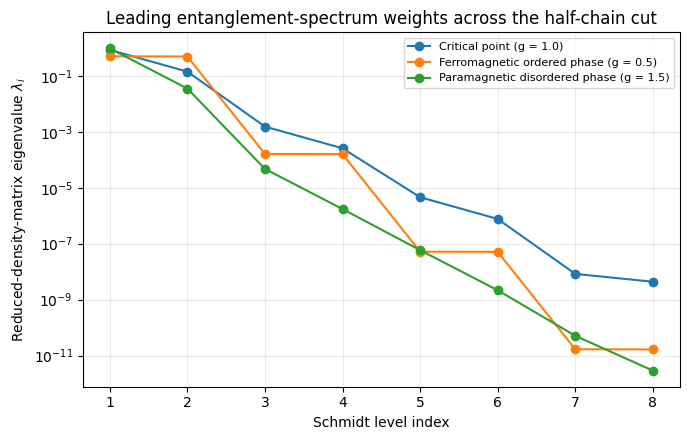

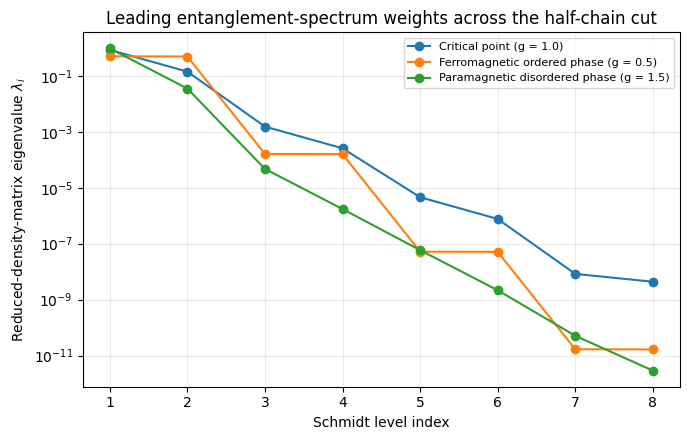

In [7]:
spectrum_figure, spectrum_axis = plt.subplots(figsize=(7, 4.5))
for phase, group in exercise_1_spectrum_table.groupby('phase'):
    ordered = group.sort_values('level')
    spectrum_axis.plot(
        ordered['level'],
        ordered['lambda'],
        marker='o',
        label=phase,
    )
spectrum_axis.set_yscale('log')
spectrum_axis.set_xlabel('Schmidt level index')
spectrum_axis.set_ylabel('Reduced-density-matrix eigenvalue $\lambda_i$')
spectrum_axis.set_title('Leading entanglement-spectrum weights across the half-chain cut')
spectrum_axis.grid(alpha=0.25)
spectrum_axis.legend(fontsize=8)
spectrum_figure.tight_layout()
spectrum_figure

Caption: the critical spectrum decays the slowest, so more Schmidt sectors carry visible weight across the cut. The accompanying retained-weight table translates that directly into MPS language: a small bond dimension $\chi$ keeps less Schmidt weight at criticality than it does away from the critical point, so the critical ground state is the least compressible across this cut.

Caption: the exact summary table reports the ground energy and both half-chain entropies for the three TFIM reference points on equal footing. Interpretation: the critical row should show the largest entropies, while the off-critical rows provide the lower-entanglement comparison cases that anchor the expected area-law saturation.

## 1/c Renyi-2 And The SWAP-Operator Identity

For $\alpha = 2$, the Renyi entropy is

$$S_2(A) = -\log\mathrm{tr}(\rho_A^2).$$

The quantity $\mathrm{tr}(\rho_A^2)$ is the purity. It has two extremal limits that are useful as checks: for a pure product state across the cut, $\rho_A$ is itself pure and $\mathrm{tr}(\rho_A^2)=1$, so $S_2(A)=0$; for a maximally mixed reduced density matrix on a subsystem of dimension $d_A$, $\mathrm{tr}(\rho_A^2)=1/d_A$, so $S_2(A)=\log d_A$.

The SWAP identity used later for neural quantum states is derived by writing the reduced density matrix in the computational basis and tracing over $B$. For $\rho = |\psi\rangle\langle\psi|$ with amplitudes $\psi_{ab}$,

$$\mathrm{tr}(\rho_A^2) = \sum_{a,a',b,b'} \psi_{ab} \psi^*_{a'b} \psi_{a'b'} \psi^*_{ab'} = \langle \psi \otimes \psi | \mathrm{SWAP}_A | \psi \otimes \psi \rangle,$$

where $\mathrm{SWAP}_A$ exchanges only the subsystem-$A$ degrees of freedom between two replicas and leaves $B$ untouched. In plain language, the estimator checks whether two sampled copies of the state still agree after the $A$ part is swapped. More generally, $\mathrm{tr}(\rho_A^\alpha) = \langle \psi^{\otimes \alpha} | \mathrm{SWAP}_A^{(\alpha)} | \psi^{\otimes \alpha} \rangle$ uses a cyclic permutation of $\alpha$ replicas, but each extra replica makes the estimator more expensive and noisier.

Direct access to the full $\rho_A$ or to all of its eigenvalues is not efficient for a neural quantum state in general because $\rho_A$ has dimension $2^{|A|} \times 2^{|A|}$, so reconstructing it requires exponentially many amplitudes or matrix elements. On a sampled ansatz one can estimate low-order traces such as $\mathrm{tr}(\rho_A^2)$, but not routinely reconstruct the entire spectrum for anything beyond tiny systems.


In [8]:
exercise_1_swap_identity = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'purity_from_trace_rho2': float(np.trace(rho @ rho).real),
        'purity_from_exp_minus_S2': float(np.exp(-exact['half_partition_renyi2'])),
    }
    for label, exact in exercise_1_exact.items()
    for rho in [observables.reduced_density_matrix(exact['ground_state'], subsystem_sites)]
]).sort_values('g').reset_index(drop=True)

exercise_1_swap_identity

,phase,g,purity_from_trace_rho2,purity_from_exp_minus_S2
0,Ferromagnetic ordered phase (g = 0.5),0.5,0.499706,0.499706
1,Critical point (g = 1.0),1.0,0.752360,0.752360
2,Paramagnetic disordered phase (g = 1.5),1.5,0.931673,0.931673


Caption: the SWAP purity check matches the direct trace evaluation for every phase. Interpretation: this exact agreement validates the Renyi-2 identity that is later reused for sampled neural-quantum-state estimators.

## 1/d Interpreting $S_1$ And $S_2$

For gapped one-dimensional ground states, the entanglement follows an area law: $S_1(A)$ and $S_2(A)$ stay $O(1)$ across a fixed boundary cut instead of growing proportionally to $|A|$. A volume-law state is the opposite extreme, with entropy that scales linearly with $|A|$. Long-range entanglement is different again: it is not just large entropy, but entropy structure that cannot be reduced to a short-range boundary contribution alone.

The tail of the entanglement spectrum matters more for $S_1$ than for $S_2$. Von Neumann entropy weights every nonzero Schmidt value through $-\lambda \log \lambda$, so tiny Schmidt coefficients still contribute. Renyi-2 emphasizes the larger Schmidt values through $\sum_i \lambda_i^2$, which makes it less sensitive to the smallest part of the spectrum. That difference is why $S_1$ reacts more strongly to weak long tails in the spectrum, while $S_2$ is the more compact summary of the dominant Schmidt sectors.


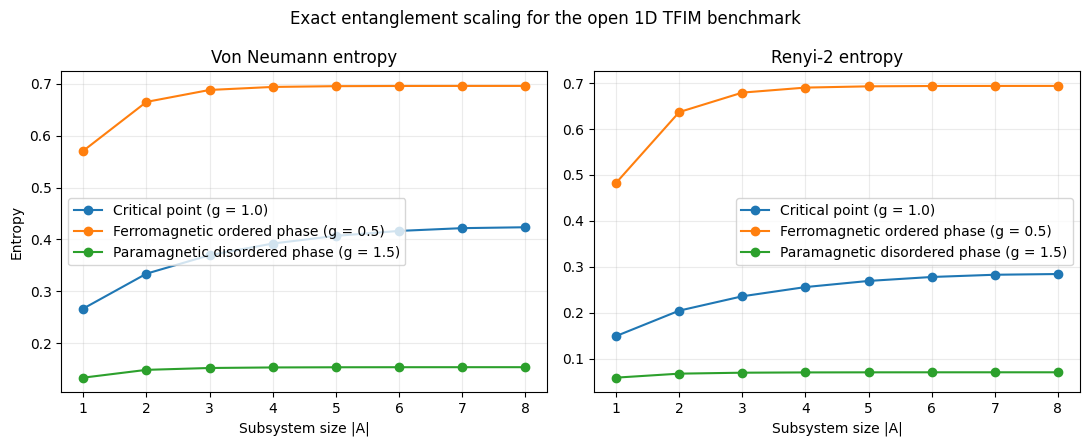

In [9]:
exercise_1_entropy_scan = pd.concat([
    exact['entropy_table'].assign(phase=phase_labels[label], g=g_values[label])
    for label, exact in exercise_1_exact.items()
], ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
for phase, group in exercise_1_entropy_scan.groupby('phase'):
    ordered = group.sort_values('subsystem_size')
    axes[0].plot(ordered['subsystem_size'], ordered['von_neumann'], marker='o', label=phase)
    axes[1].plot(ordered['subsystem_size'], ordered['renyi2'], marker='o', label=phase)

axes[0].set_title('Von Neumann entropy')
axes[1].set_title('Renyi-2 entropy')
for axis in axes:
    axis.set_xlabel('Subsystem size |A|')
    axis.grid(alpha=0.25)
axes[0].set_ylabel('Entropy')
axes[0].legend()
axes[1].legend()
figure.suptitle('Exact entanglement scaling for the open 1D TFIM benchmark')
figure.tight_layout()

Caption: the entanglement-scaling plot tracks $S_1$ and $S_2$ versus subsystem size on the same $L = 16$ open chain. Interpretation: the critical curve stays broader across subsystem sizes, while the ferromagnetic and paramagnetic curves flatten sooner on this finite benchmark.

In [10]:
exercise_1_scaling_summary = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'heuristic_log_fit_slope_S2': exact['scaling_fit']['slope'] if exact['scaling_fit'] is not None else np.nan,
        'heuristic_log_fit_r2_S2': exact['scaling_fit']['r_squared'] if exact['scaling_fit'] is not None else np.nan,
        'finite_size_reading': 'Off-critical ordered reference' if np.isclose(g_values[label], 0.5) else ('Critical reference point' if np.isclose(g_values[label], 1.0) else 'Off-critical disordered reference'),
    }
    for label, exact in exercise_1_exact.items()
]).sort_values('g').reset_index(drop=True)

exercise_1_scaling_summary

,phase,g,heuristic_log_fit_slope_S2,heuristic_log_fit_r2_S2,finite_size_reading
0,Ferromagnetic ordered phase (g = 0.5),0.5,0.091916,0.777056,Off-critical ordered reference
1,Critical point (g = 1.0),1.0,0.066499,0.980511,Critical reference point
2,Paramagnetic disordered phase (g = 1.5),1.5,0.005032,0.773604,Off-critical disordered reference


Caption: the heuristic log-fit summary is a finite-size diagnostic for the $L = 16$ benchmark, not an asymptotic scaling claim. Interpretation: it compactly shows that the critical point is the most consistent with enhanced logarithmic growth across the accessible subsystem sizes.

## Final Conclusions

Exact diagonalization on the open $L = 16$ TFIM chain gives a compact report-quality answer to Problem 1. The notebook now makes the full methodology explicit: the same computational basis is used to index specific product states, solve for the TFIM ground state, reshape the exact statevector across the half-chain cut, and build $\rho_A$. This directly satisfies Problem 1(a)'s requirement that the benchmark give access to both chosen product states and Hamiltonian ground states in one basis convention.

The reduced-density-matrix eigenvalues are the squared Schmidt coefficients, so the spectrum and retained-weight table answer Problem 1(b) in MPS terms: the critical point has the slowest-decaying spectrum and therefore needs the largest bond dimension to keep the same Schmidt weight, whereas the two off-critical points are more compressible. The subsystem scan answers the scaling question from Problem 1(b) and 1(d): on this finite open chain the off-critical points show the expected area-law saturation trend, while the critical point is the case most consistent with enhanced, near-logarithmic growth over the accessible subsystem sizes rather than a volume law.

For probe comparison, $S_1$ is evaluated exactly from the full $\rho_A$, but that route is not scalable for a neural quantum state because it would require reconstructing the full reduced density matrix. By contrast, $S_2$ follows from the exact SWAP identity verified in the notebook, so it remains the natural Monte Carlo-friendly probe. The final physical comparison is therefore: $S_1$ is the more tail-sensitive diagnostic and changes more under truncation of tiny Schmidt coefficients, while $S_2$ emphasizes the dominant Schmidt sectors and is the practical estimator to carry into the sampled NQS setting.

## Limitations

This report answers Problem 1 on a finite open `L = 16` chain only. The log-fit table is a finite-size diagnostic rather than proof of asymptotic scaling, the plotted entanglement spectrum shows only the leading Schmidt weights, and the notebook does not attempt to reconstruct `S_1` from a sampled neural quantum state because that would require the full reduced density matrix rather than a scalable Monte Carlo estimator.


## Export Exercise 1 Artifacts

Persist the exact summary, the Schmidt-compressibility table, the SWAP check, and the report figures for later report assembly.

In [11]:
summary_paths = save_report_table(exercise_1_summary, 'exercise_1_exact_summary', output_dir=exercise_output_dir)
compressibility_paths = save_report_table(exercise_1_compressibility, 'exercise_1_schmidt_compressibility', output_dir=exercise_output_dir)
spectrum_paths = save_report_table(exercise_1_spectrum_table, 'exercise_1_entanglement_spectrum', output_dir=exercise_output_dir)
swap_paths = save_report_table(exercise_1_swap_identity, 'exercise_1_swap_identity', output_dir=exercise_output_dir)
scaling_paths = save_report_table(exercise_1_scaling_summary, 'exercise_1_scaling_summary', output_dir=exercise_output_dir)
figure_path = save_report_figure(figure, 'exercise_1_entropy_scaling', output_dir=exercise_output_dir)
spectrum_figure_path = save_report_figure(spectrum_figure, 'exercise_1_entanglement_spectrum', output_dir=exercise_output_dir)

build_output_manifest([
    {'section': 'exercise_1', 'name': 'exercise_1_exact_summary', 'path': str(summary_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_schmidt_compressibility', 'path': str(compressibility_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_entanglement_spectrum', 'path': str(spectrum_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_swap_identity', 'path': str(swap_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_scaling_summary', 'path': str(scaling_paths['csv'])},
    {'section': 'exercise_1', 'name': 'exercise_1_entropy_scaling', 'path': str(figure_path)},
    {'section': 'exercise_1', 'name': 'exercise_1_entanglement_spectrum_figure', 'path': str(spectrum_figure_path)},
])

,section,name,path
0,exercise_1,exercise_1_entanglement_spectrum,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,exercise_1,exercise_1_entanglement_spectrum_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,exercise_1,exercise_1_entropy_scaling,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,exercise_1,exercise_1_exact_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,exercise_1,exercise_1_scaling_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
5,exercise_1,exercise_1_schmidt_compressibility,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
6,exercise_1,exercise_1_swap_identity,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
